In [1]:
!git clone https://github.com/serengil/deepface

Cloning into 'deepface'...
remote: Enumerating objects: 9525, done.
remote: Counting objects: 100% (728/728), done.
remote: Compressing objects: 100% (393/393), done.
remote: Total 9525 (delta 373), reused 335 (delta 335), pack-reused 8797 (from 3)
Receiving objects: 100% (9525/9525), 57.09 MiB | 21.11 MiB/s, done.
Resolving deltas: 100% (6232/6232), done.


In [5]:
import os
os.listdir()

['.config', 'deepface', 'sample_data']

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os

os.listdir("/content/drive/MyDrive/Colab Notebooks")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Copy of Untitled0.ipynb',
 'Untitled (2)',
 'Untitled0.ipynb',
 'mnist.ipynb',
 'Untitled1.ipynb',
 'Copy of finalproject (2).ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'Another copy of finalproject.ipynb',
 'samarthS_finalproject.ipynb',
 'Copy of facialrecognition (1).ipynb',
 'Untitled4.ipynb',
 'Copy of facialrecognition.ipynb',
 'Copy of finalproject (1).ipynb',
 'Copy of finalproject.ipynb',
 'Untitled (1)',
 'UW_EMA.ipynb',
 'Untitled',
 'Copy of UW_EMA (1).ipynb',
 'Another copy of UW_EMA (1).ipynb',
 'AI4L.ipynb',
 'UW_EMA (1).ipynb',
 'Untitled5.ipynb',
 'Untitled6.ipynb',
 'Untitled7.ipynb',
 'finalprojectcopy.ipynb']

In [11]:
import nbformat

file = "/content/drive/MyDrive/Colab Notebooks/finalprojectcopy.ipynb"

with open(file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# remove broken widget metadata causing GitHub error
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(file, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Fixed notebook saved")

Fixed notebook saved


In [13]:
import nbformat

file = "/content/drive/MyDrive/Colab Notebooks/finalprojectcopy.ipynb"

with open(file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# 1. remove top-level widget metadata
nb.get("metadata", {}).pop("widgets", None)

# 2. remove widget state from ALL cells
for cell in nb.get("cells", []):
    if "metadata" in cell:
        cell["metadata"].pop("widgets", None)
        cell["metadata"].pop("execution", None)
        cell["metadata"].pop("trusted", None)

    # sometimes widget state is inside outputs
    if "outputs" in cell:
        for out in cell["outputs"]:
            if isinstance(out, dict):
                out.pop("data", None)
                out.pop("metadata", None)

with open(file, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Fully cleaned notebook saved.")

Fully cleaned notebook saved.


In [ ]:
!git clone https://github.com/michaeltrang08/facial-recognition-test-pics #test pics and audio

Cloning into 'facial-recognition-test-pics'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 135 (delta 24), reused 15 (delta 15), pack-reused 106 (from 1)
Receiving objects: 100% (135/135), 40.61 MiB | 44.81 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [ ]:
#copied from the transcrive audio notebook
!pip install git+https://github.com/neuml/txtai#egg=txtai[api,pipeline]

# Get test data
#!wget -N https://github.com/neuml/txtai/releases/download/v3.5.0/tests.tar.gz
#!wget -N https://github.com/michaeltrang08/facial-recognition-test-pics/tree/main/audios
#!tar -xvzf tests.tar.gz

DEPRECATION: git+https://github.com/neuml/txtai#egg=txtai[api,pipeline] contains an egg fragment with a non-PEP 508 name pip 25.0 will enforce this behaviour change. A possible replacement is to use the req @ url syntax, and remove the egg fragment. Discussion can be found at https://github.com/pypa/pip/issues/11617
  Cloning https://github.com/neuml/txtai to /tmp/pip-install-_voutxpu/txtai_ba020930cfe94501ac1e552dcd498bd5
  Running command git clone --filter=blob:none --quiet https://github.com/neuml/txtai /tmp/pip-install-_voutxpu/txtai_ba020930cfe94501ac1e552dcd498bd5
  Resolved https://github.com/neuml/txtai to commit 12c8b52b5ed013ab4ad594164e23d5fa68e2ba26
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 MB 19.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend depe

In [ ]:
!wget -N https://github.com/michaeltrang08/facial-recognition-test-pics/tree/main/audios

--2024-07-02 16:54:23--  https://github.com/michaeltrang08/facial-recognition-test-pics/tree/main/audios
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘audios’

audios                  [ <=>                ] 245.14K  --.-KB/s    in 0.02s   

Last-modified header missing -- time-stamps turned off.
2024-07-02 16:54:23 (10.4 MB/s) - ‘audios’ saved [251023]



In [ ]:
from txtai.pipeline import Transcription

# Create transcription model
transcribe = Transcription()

No model was supplied, defaulted to facebook/wav2vec2-base-960h and revision 55bb623 (https://huggingface.co/facebook/wav2vec2-base-960h).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/wav2vec2-base-960h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You sho

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

In [ ]:
from IPython.display import Audio, display

files = ["audio2.wav"]
files = ["facial-recognition-test-pics/audios/%s" % x for x in files]

for x, text in enumerate(transcribe(files)):
  display(Audio(files[x]))
  print(text)
  print()

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


Maybe next time



In [ ]:
# Transcribe files
transcribe = Transcription("openai/whisper-base")
for text in transcribe(files):
  print(text)
  txt = text

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Maybe next time.


In [ ]:
print(txt)

Maybe next time.


In [ ]:
!pip3 install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 18.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.6.0-py2.py3-none-any.whl size=117029 sha256=95bd96c5832102197d6f0d900808700453ec81c44c339e06ec51bd8c69604d91
  Stored in directory: /root/.cache/pip/wheels/d6/6d/5d/5b73fa0f46d01a793713f8859201361e9e581ced8c75e5c6a3
Successfully built fire
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.2
    Uninstalling protobuf-3.20.2:
      Successfully uninstalled protobuf-3.20.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. T

In [ ]:
from deepface import DeepFace
import numpy as np
import pandas as pd
import cv2
import dlib
import imutils
import matplotlib.pyplot as plt

In [ ]:
img1_path = 'facial-recognition-test-pics/kanye1.jpg'
img2_path = 'facial-recognition-test-pics/kanye2.jpg'

In [ ]:
#after this comment the code belongs to the intro notebook

In [ ]:
detector = dlib.get_frontal_face_detector()

In [ ]:
# convenience function to take co-ordinates and convert them to bbox format
# bbox = Bounding Box (used to mark sections of an image)
def convert_and_trim_bb(image, rect):
	# extract the starting and ending (x, y)-coordinates of the
	# bounding box
	startX = rect.left()
	startY = rect.top()
	endX = rect.right()
	endY = rect.bottom()
	# ensure the bounding box coordinates fall within the spatial
	# dimensions of the image
	startX = max(0, startX)
	startY = max(0, startY)
	endX = min(endX, image.shape[1])
	endY = min(endY, image.shape[0])
	# compute the width and height of the bounding box
	w = endX - startX
	h = endY - startY
	# return our bounding box coordinates
	return (startX, startY, w, h)

In [ ]:
def detect_faces(detector, image_path, is_CNN=False):
  """
  @brief  Takes in a detector and a path to an image, and performs
          detects human faces.
  """
  image = cv2.imread(image_path, cv2.IMREAD_COLOR)
  image = imutils.resize(image, width=600)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  rects = detector(image)

  if is_CNN:
    boxes = [convert_and_trim_bb(image, r.rects) for r in rects]
  else:
    boxes = [convert_and_trim_bb(image, r) for r in rects]

  for (x, y, w, h) in boxes:
	  # draw the bounding box on our image
	  cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

  plt.figure(figsize=(10,20))
  plt.imshow(image)

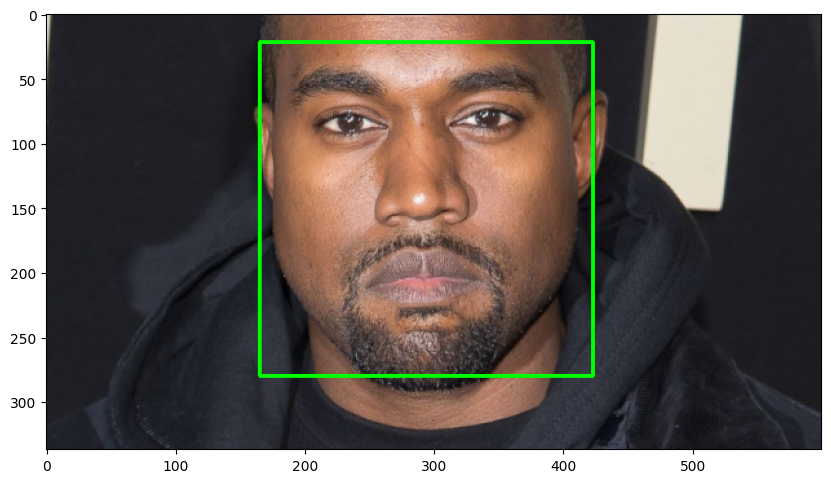

In [ ]:
img1 = detect_faces(detector, img1_path)

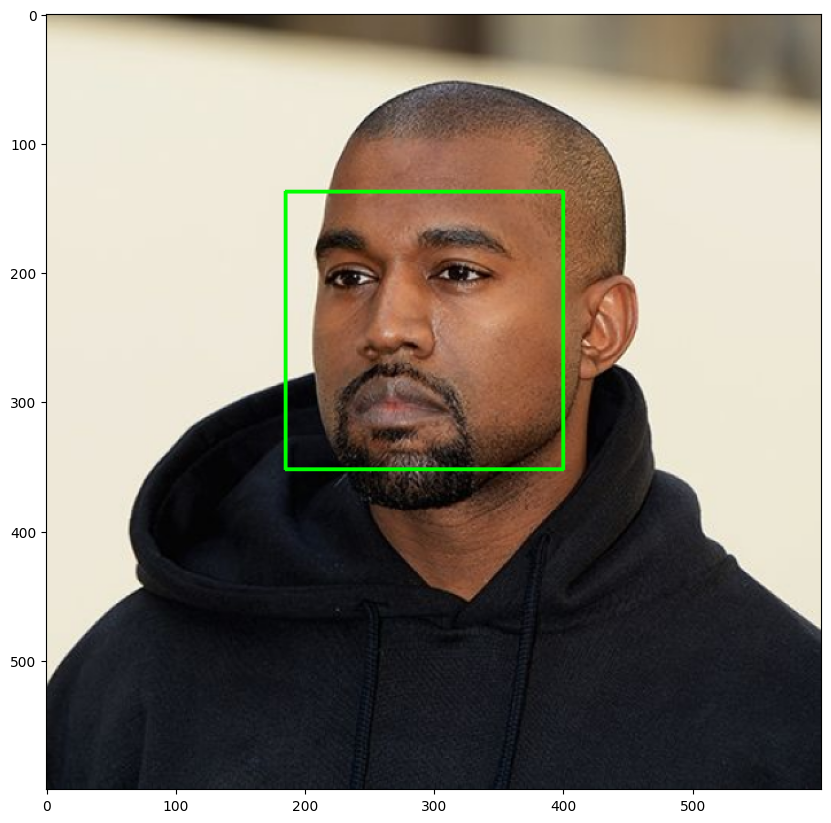

In [ ]:
img2 = detect_faces(detector, img2_path)

In [ ]:
model_name = 'VGG-Face'

In [ ]:
backend_name = 'OpenCV'

In [ ]:
compare = DeepFace.verify(img1_path = img1_path, img2_path = img2_path, model_name = model_name)


{'verified': True,
 'distance': 0.3951397120043054,
 'threshold': 0.68,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 236,
   'y': -56,
   'w': 482,
   'h': 482,
   'left_eye': (566, 134),
   'right_eye': (378, 142)},
  'img2': {'x': 145,
   'y': 105,
   'w': 166,
   'h': 166,
   'left_eye': (265, 167),
   'right_eye': (195, 171)}},
 'time': 1.71}

In [ ]:
#face_found.head() these dont work because its not a array or smth
#we are going to create a class with functions that iterates throught the database